Data Ingestion + Validation + Cleaning + Preparation

In [91]:
import pandas as pd

In [92]:
data = pd.read_csv('/content/drive/MyDrive/Unified Mentor/Customer Segmentation & Churn Pattern Analytics in European Banking/Dataset/European_Bank.csv')

In [93]:
data.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [94]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [95]:
data.duplicated().sum()

np.int64(0)

In [96]:
data.drop(['Year','CustomerId','Surname'],axis=1,inplace=True)

In [97]:
data['IsActiveMember'].value_counts()

,count
IsActiveMember,
1,5151
0,4849


In [98]:
data['NumOfProducts'].value_counts()

,count
NumOfProducts,
1,5084
2,4590
3,266
4,60


In [99]:
data[data['NumOfProducts'] <= 0]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [100]:
data['HasCrCard'].value_counts()

,count
HasCrCard,
1,7055
0,2945


In [101]:
data.groupby('IsActiveMember')['Exited'].mean()

,Exited
IsActiveMember,
0,0.268509
1,0.142691


In [102]:
# Inactive customers have higher churn

In [103]:
binary_cols = ['Exited', 'IsActiveMember', 'HasCrCard']

for col in binary_cols:
    print(col, data[col].unique())

Exited [1 0]
IsActiveMember [1 0]
HasCrCard [1 0]


In [104]:
data['Exited'].value_counts(normalize=True)

,proportion
Exited,
0,0.7963
1,0.2037


In [105]:
# 20% churn rate

In [106]:
data[data['Exited'] == 1].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.0
mean,645.351497,44.837997,4.932744,91108.539337,1.475209,0.699067,0.360825,101465.677531,1.0
std,100.321503,9.761562,2.936106,58360.794816,0.801521,0.458776,0.480358,57912.418071,0.0
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,1.0
25%,578.000000,38.000000,2.000000,38340.020000,1.000000,0.000000,0.000000,51907.720000,1.0
50%,646.000000,45.000000,5.000000,109349.290000,1.000000,1.000000,0.000000,102460.840000,1.0
75%,716.000000,51.000000,8.000000,131433.330000,2.000000,1.000000,1.000000,152422.910000,1.0
max,850.000000,84.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199808.100000,1.0


In [107]:
#  Mostly these customers are chruning
# 1. Middle-aged (~45 years)
# 2. Moderately experienced (~5 years tenure)
# 3. Holds high balance
# 4. Owns few products
# 5. Inactive before leaving

In [108]:
data['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [109]:
data['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [110]:
data['AgeGroup'] = pd.cut(data['Age'], bins=[0,30,45,60,100], labels=['<30','30-45','46-60','60+'])

In [111]:
data['CreditBand'] = pd.cut(data['CreditScore'], bins=[300,600,700,850], labels=['Low','Medium','High'])

In [112]:
data['TenureGroup'] = pd.cut(data['Tenure'],bins=[-1,3,7,10],labels=['New','Mid-term','Long-term'])

In [113]:
data['BalanceSegment'] = pd.cut(data['Balance'], bins=[-1,0,100000,250000],labels=['Zero','Low','High'])

In [114]:
data[['AgeGroup','CreditBand','TenureGroup','BalanceSegment']].head()

,AgeGroup,CreditBand,TenureGroup,BalanceSegment
0,30-45,Medium,New,Zero
1,30-45,Medium,New,Low
2,30-45,Low,Long-term,High
3,30-45,Medium,New,Zero
4,30-45,High,New,High


In [115]:
data['AgeGroup'].value_counts()

,count
AgeGroup,
30-45,5921
<30,1968
46-60,1647
60+,464


In [116]:
data['BalanceSegment'].value_counts()

,count
BalanceSegment,
High,4798
Zero,3617
Low,1584


In [117]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      10000 non-null  int64   
 1   Geography        10000 non-null  object  
 2   Gender           10000 non-null  object  
 3   Age              10000 non-null  int64   
 4   Tenure           10000 non-null  int64   
 5   Balance          10000 non-null  float64 
 6   NumOfProducts    10000 non-null  int64   
 7   HasCrCard        10000 non-null  int64   
 8   IsActiveMember   10000 non-null  int64   
 9   EstimatedSalary  10000 non-null  float64 
 10  Exited           10000 non-null  int64   
 11  AgeGroup         10000 non-null  category
 12  CreditBand       10000 non-null  category
 13  TenureGroup      10000 non-null  category
 14  BalanceSegment   9999 non-null   category
dtypes: category(4), float64(2), int64(7), object(2)
memory usage: 899.2+ KB


In [118]:
data.dropna(inplace=True)

Churn Distribution Analysis


In [119]:
#overall churn rate
churn_rate = data['Exited'].mean()
print("Overall Churn Rate:", round(churn_rate,4))

Overall Churn Rate: 0.2036


In [120]:
#Segment-wise Churn Rates
# 1. age-wise
data.groupby('AgeGroup')['Exited'].mean().sort_values(ascending=False)

/tmp/ipykernel_1580/1187470746.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('AgeGroup')['Exited'].mean().sort_values(ascending=False)


,Exited
AgeGroup,
46-60,0.511233
60+,0.247845
30-45,0.157264
<30,0.075203


In [121]:
# 2. Geography-wise Churn
data.groupby('Geography')['Exited'].mean().sort_values(ascending=False)

,Exited
Geography,
Germany,0.324432
Spain,0.166397
France,0.161548


In [122]:
# 3. Balance Segment Churn
data.groupby('BalanceSegment')['Exited'].mean().sort_values(ascending=False)

/tmp/ipykernel_1580/2099619416.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('BalanceSegment')['Exited'].mean().sort_values(ascending=False)


,Exited
BalanceSegment,
High,0.252188
Low,0.205808
Zero,0.138236


In [123]:
# 4. Tenure-wise Churn
data.groupby('TenureGroup')['Exited'].mean().sort_values(ascending=False)

/tmp/ipykernel_1580/701974793.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('TenureGroup')['Exited'].mean().sort_values(ascending=False)


,Exited
TenureGroup,
New,0.211187
Long-term,0.204482
Mid-term,0.196446


In [124]:
#Churn Contribution by Segment Size
# 1.Geography contribution
churned = data[data['Exited'] == 1]
churned['Geography'].value_counts(normalize=True)

,proportion
Geography,
Germany,0.399804
France,0.397839
Spain,0.202358


In [125]:
# 2. Age wise contribution
churned['AgeGroup'].value_counts(normalize=True)

,proportion
AgeGroup,
30-45,0.457269
46-60,0.413556
<30,0.072692
60+,0.056483


In [126]:
# 3. balance wise
churned['BalanceSegment'].value_counts(normalize=True)

,proportion
BalanceSegment,
High,0.594303
Zero,0.245580
Low,0.160118


In [127]:
# 4. tenure wise
churned['TenureGroup'].value_counts(normalize=True)

,proportion
TenureGroup,
Mid-term,0.385560
New,0.363458
Long-term,0.250982


In [128]:
#Comparison: Churned vs Retained Profiles
data.groupby('Exited')[['Age','Balance','IsActiveMember','NumOfProducts']].mean()

,Age,Balance,IsActiveMember,NumOfProducts
Exited,,,,
0,37.408389,72745.296779,0.554565,1.544267
1,44.841356,91030.057240,0.360511,1.474460


In [129]:
# insights
# 1. High-Balance Customers Are Churning
# 2. Older Customers Churn More
# 3. Inactive users are far more likely to churn
# 4. Churn customers has less no. of products

Comparative Demographic Analysis

In [130]:
# 1. Gender-Based Churn Differences
data.groupby('Gender')['Exited'].mean()

,Exited
Gender,
Female,0.250715
Male,0.164406


In [131]:
# 2. Geography–Age Interaction Analysis
pd.pivot_table(data,values='Exited', index='Geography',columns='AgeGroup',aggfunc='mean')

/tmp/ipykernel_1580/1444036713.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(data,values='Exited', index='Geography',columns='AgeGroup',aggfunc='mean')


AgeGroup,<30,30-45,46-60,60+
Geography,,,,
France,0.049133,0.123498,0.457944,0.199134
Germany,0.123620,0.260930,0.673307,0.389381
Spain,0.085954,0.124747,0.406566,0.208333


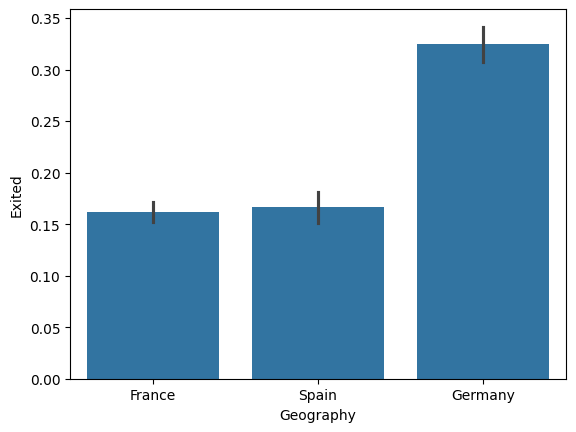

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Geography', y='Exited', data=data)
plt.show()

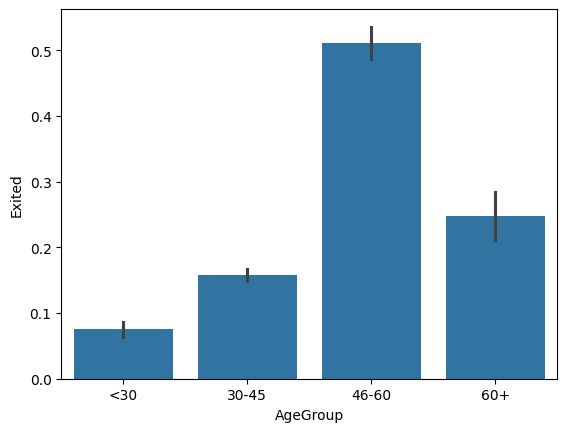

In [157]:
sns.barplot(x='AgeGroup', y='Exited', data=data)
plt.show()

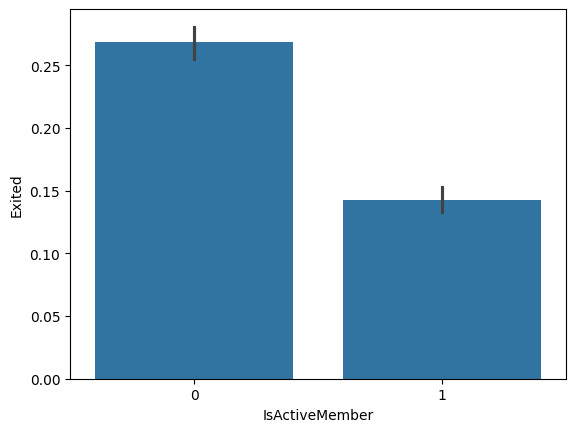

In [159]:
sns.barplot(x='IsActiveMember', y='Exited', data=data)
plt.show()

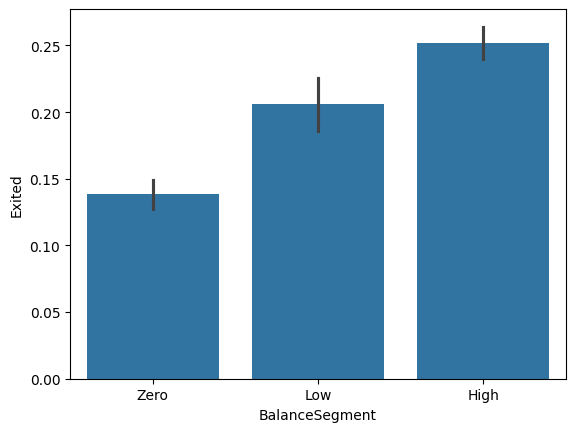

In [160]:
sns.barplot(x='BalanceSegment', y='Exited', data=data)
plt.show()

In [132]:
#While France and Spain show comparable churn trends, Germany deviates significantly with consistently higher attrition rates.

In [133]:
# Credit Band vs Churn
data.groupby('CreditBand')['Exited'].mean()

/tmp/ipykernel_1580/873415590.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('CreditBand')['Exited'].mean()


,Exited
CreditBand,
Low,0.216895
Medium,0.197013
High,0.198652


In [134]:
# Balance vs Churn
data.groupby('BalanceSegment')['Exited'].mean()

/tmp/ipykernel_1580/2680283908.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('BalanceSegment')['Exited'].mean()


,Exited
BalanceSegment,
Zero,0.138236
Low,0.205808
High,0.252188


In [135]:
# salary vs churn
data.groupby('Exited')['EstimatedSalary'].mean()


,EstimatedSalary
Exited,
0,99738.391772
1,101475.702913


In [136]:
# The analysis shows that churn is not restricted to financially weak customers.
# Even customers with high credit scores and significant account balances exhibit churn behavior,
# indicating that financial stability alone does not ensure retention.
# Instead, engagement and behavioral factors play a more critical role.

High-Value Customer Churn Analysis

In [138]:
# 1. Identify High-Balance Churners
high_value = data[data['BalanceSegment'] == 'High']
high_value['Exited'].mean()

np.float64(0.25218841183826596)

In [141]:
# overall churn
data['Exited'].mean()

np.float64(0.20362036203620362)

In [142]:
# High-balance customers exhibit comparable or higher churn rates,
# indicating that valuable customers are not being effectively retained.

In [144]:
#How many premium customers are lost
high_value_churn = high_value[high_value['Exited'] == 1]
len(high_value_churn)

1210

In [145]:
# 2. Compare Salary vs Balance Churn Patterns
# churn is more closely related to customer engagement with the bank rather than overall income.

<Axes: xlabel='Exited', ylabel='Balance'>

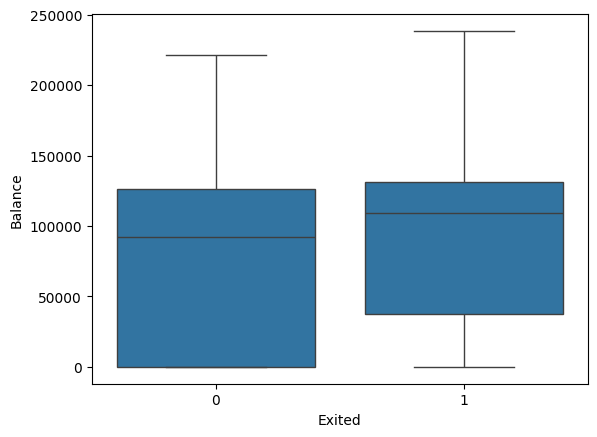

In [146]:
import seaborn as sns

sns.boxplot(x='Exited', y='Balance', data=data)

In [147]:
# salary levels show minimal variation between churned and retained customers, account balance demonstrates a significant difference

In [150]:
# 3. Quantify Revenue Risk from Churn
# Total balance lost due to churn
revenue_loss = data[data['Exited'] == 1]['Balance'].sum()
print(revenue_loss)

185337196.54


In [151]:
# High-value loss
high_value_loss = high_value_churn['Balance'].sum()
print(high_value_loss)

159238792.91


In [153]:
# Contribution of high-value churn
# How much of total loss comes from premium customers
high_value_loss / revenue_loss

np.float64(0.8591842106321741)

In [154]:
# A significant portion of total revenue loss is driven by high-balance customers,
# indicating that churn is not limited to low-value segments